## Optimal 1-D Measurement

In [1]:
from bivariate.dist import *
from bivariate.utils import *
from bivariate.fcdn import Denoiser
from sklearn.decomposition import PCA
import bivariate.inverse as inv
import matplotlib.pyplot as plt
import torch
import numpy as np

In [2]:
import seaborn as sns
sns.set()

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

device = ('cuda' if torch.cuda.is_available() else 'cpu')

Setup Data Distribution

In [3]:
# choose distribution
dist = 'ksparse'

if dist == 'normal':
    mu = [0, 0]
    sigma = [0.4, 0.2]
    rho = 0.4

    # normal distribution
    train = normal(mu=mu, sigma=sigma, rho=rho, n=10000)
    test = normal(mu=mu, sigma=sigma, rho=rho, n=500)

# k-sparse
elif dist == 'ksparse':
    train = k_sparse(n=10000, length=0.40)
    test = k_sparse(n=1000, length=0.40)

# sum of gaussian ridges
elif dist == 'ridge':
    train = ridge(n=10000, balance=False, shrink=0.88)
    test = ridge(n=1000, balance=True, shrink=0.88)

# create torch vector
train_tr = torch.from_numpy(train).float()
test_tr = torch.from_numpy(test).float()

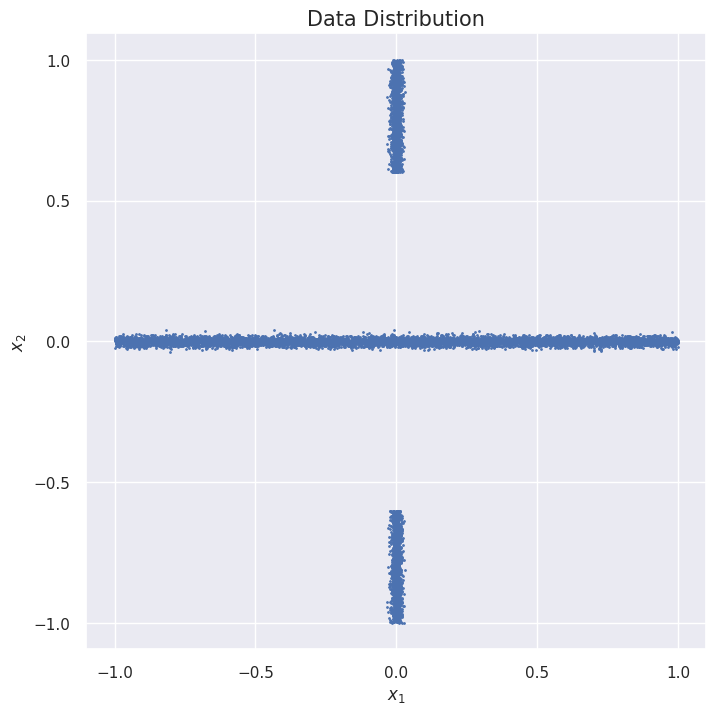

In [4]:
# plot data
fig = plt.figure(figsize=(8, 8))
plt.scatter(train[:, 0], train[:, 1], s=1)
plt.axis('equal')

plt.xlim(-1.1, 1.1)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='x', length=8)
plt.xlabel('$x_1$', fontsize=12)

plt.ylim(-1.1, 1.1)
plt.yticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='y', length=8)
plt.ylabel('$x_2$', fontsize=12)

fig_name = 'Data Distribution'
plt.title(fig_name, fontsize=15)
plt.show()

Train Denoiser

In [5]:
train_tr = torch.from_numpy(train).float()
test_tr = torch.from_numpy(test).float()

model = Denoiser(n_node=32, n_int=4, bias=True)
args = Args(train_noise=[1, 128], test_noise=32)

if dist == 'sparse':
    args = Args(train_noise=[1, 192], test_noise=128)

args.lr = 0.1
args.decay_lr = 0.98
args.batch_size = 128
args.n_epoch = 200

In [6]:
# run model training
epoch_loss, test_loss = train_simple(train_tr, test_tr, model, args)

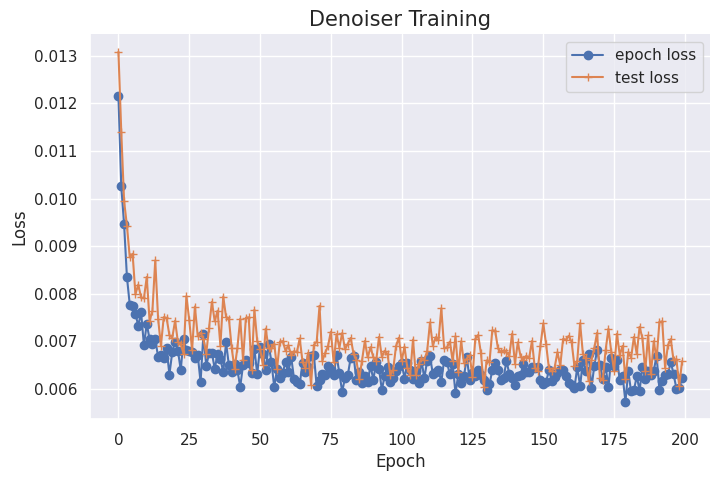

In [7]:
# plot epoch and test loss
fig = plt.figure(figsize=(8, 5))
plt.plot(epoch_loss, '-o', label='epoch loss')
plt.plot(test_loss, '-+', label='test loss')

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend()
fig_name = 'Denoiser Training'
plt.title(fig_name, fontsize=15)
plt.show()

Score Function

In [8]:
x = np.linspace(-1.2, 1.2, 21)
y = np.linspace(-1.2, 1.2, 21)

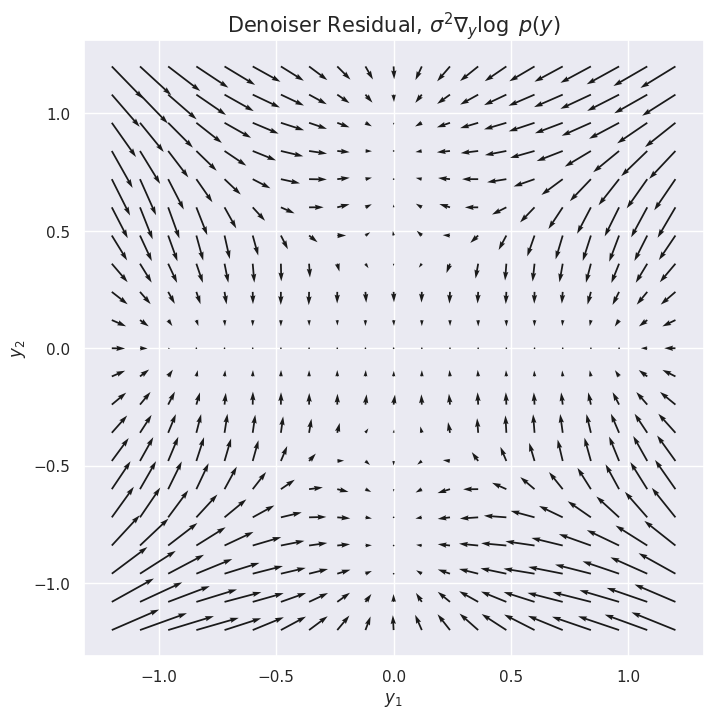

In [9]:
X, Y = np.meshgrid(x, y)
XY = np.concatenate([X.reshape(-1, 1), Y.reshape(-1, 1)], axis=1)

# compute the vector field (log prior gradient)
XY_tr = torch.from_numpy(XY).float()
with torch.no_grad():
    UV = - model(XY_tr.to(device)).detach().cpu().numpy()

U = UV[:, 0].reshape(X.shape)
V = UV[:, 1].reshape(Y.shape)

# generate the quiver plot

fig = plt.figure(figsize=(8, 8))
plt.quiver(X, Y, U, V, scale=12)

plt.xlabel('$y_1$', fontsize=12)
plt.ylabel('$y_2$', fontsize=12)

plt.axis('equal')
plt.title('Denoiser Residual, $\sigma^2 \\nabla_y \log \ p(y)$', fontsize=15)
plt.show()

Optimize 1-D Measurement

In [10]:
train_tr = torch.from_numpy(train).float()
test_tr = torch.from_numpy(test).float()

# denoiser reconstruction
solver = inv.LinearInverse(model).to(device)
solver.h = 0.20
solver.beta = 0.20

vector = torch.tensor([1, 1]).reshape(1, 2)
solver.assign(vector.float().to(device))

init_vec = solver.vector.detach().cpu().numpy().squeeze()
init_angle = np.arctan2(init_vec[1], init_vec[0])
print('Initial angle: {:.2f}'.format(init_angle / np.pi * 180))

Initial angle: 45.00


In [11]:
if dist == 'normal':
    n_epoch = 20
    loss = inv.lnopt(solver, train_tr, test_tr, device, lr=5e-4, gamma=0.99,
                     batch_size=128, n_epoch=n_epoch, verbose=False)

elif dist == 'ksparse':
    n_epoch = 10
    loss = inv.lnopt(solver, train_tr, test_tr, device,
                     batch_size=128, n_epoch=n_epoch, verbose=False)

elif dist == 'ridge':
    n_epoch = 10
    loss = inv.lnopt(solver, train_tr, test_tr, device, lr=5e-3,
                    batch_size=2048, n_epoch=n_epoch, verbose=False)

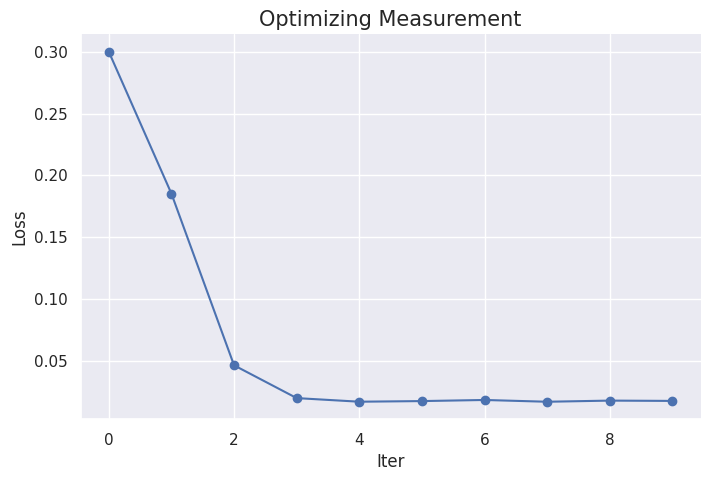

In [12]:
# plot
fig = plt.figure(figsize=(8, 5))
plt.plot(loss[1], '-o')

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.xticks(np.arange(0, n_epoch, n_epoch // 5))
plt.xlabel('Iter', fontsize=12)
plt.ylabel('Loss', fontsize=12)

fig_name = 'Optimizing Measurement'
plt.title(fig_name, fontsize=15)
plt.show()

In [13]:
opt_vector = solver.vector.detach().cpu().numpy().squeeze()
opt_rad = np.arctan2(opt_vector[1], opt_vector[0])
opt_angle = opt_rad / np.pi * 180

# wrap to [-90, 90]
if opt_angle < -90:
    opt_angle += 180

if opt_angle > 90:
    opt_angle -= 180

print('Optimal angle: {:.2f} deg'.format(opt_angle))

Optimal angle: 74.36 deg


Analysis 1-D Measurements

In [14]:
theta = np.linspace(-90, 90, 91)

error_proj = np.zeros_like(theta)
error_dns = np.zeros_like(theta)
test_torch = test_tr.to(device)

# denoiser reconstruction
solver = inv.LinearInverse(model).to(device)
# set parameters
solver.h = 0.20
solver.beta = 0.20

for i, t in enumerate(theta):
    angle = np.radians(t)
    vector = np.array([np.cos(angle),
                        np.sin(angle)]).reshape(1, 2)
    # projection
    proj = (vector.T @ vector @ test.T).T

    # linear inverse
    solver.assign(torch.tensor(vector).float().to(device))

    # run linear inverse
    with torch.no_grad():
        recon = solver.average(test_torch, sample=128)
        recon = recon.cpu().detach().numpy()

    error_proj[i] = ((test - proj).flatten() ** 2).sum() / test.shape[0]
    error_dns[i] = ((test - recon).flatten() ** 2).sum() / test.shape[0]

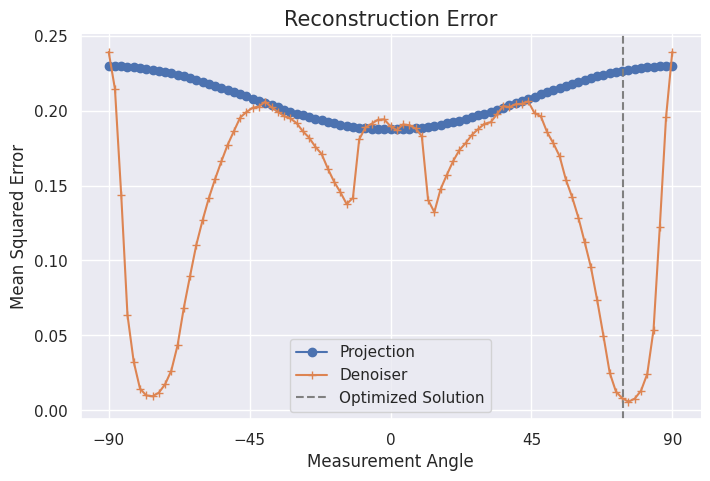

In [15]:
fig = plt.figure(figsize=(8, 5))

plt.plot(theta, error_proj, '-o', label='Projection')
plt.plot(theta, error_dns, '-+', label='Denoiser')
plt.axvline(opt_angle, color='gray', linestyle='--', label='Optimized Solution')

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.xlabel('Measurement Angle', fontsize=12)
plt.xticks(np.arange(-90, 91, 45))
plt.ylabel('Mean Squared Error', fontsize=12)

plt.legend()
fig_name = 'Reconstruction Error'
plt.title('Reconstruction Error', fontsize=15)
plt.show()

Visualization

In [16]:
m = np.linspace(-1, 1, 100)
recon = np.zeros((100, 2))
recon[:, 0] = m

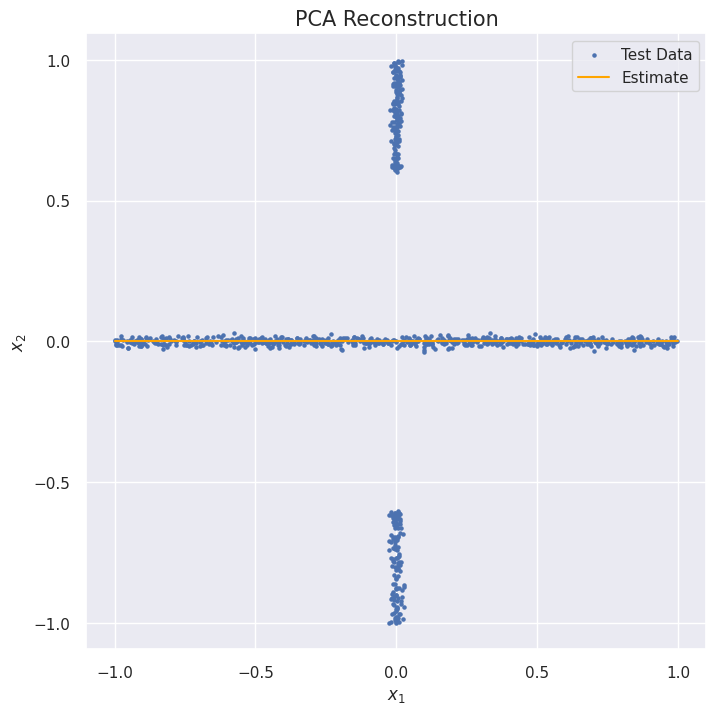

In [17]:
# plot data
fig = plt.figure(figsize=(8, 8))
plt.scatter(test[:, 0], test[:, 1], s=5,
            label='Test Data')
plt.plot(recon[:, 0], recon[:, 1], color='orange',
            label='Estimate')
plt.axis('equal')

plt.xlim(-1.1, 1.1)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='x', length=8)
plt.xlabel('$x_1$', fontsize=12)

plt.ylim(-1.1, 1.1)
plt.yticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='y', length=8)
plt.ylabel('$x_2$', fontsize=12)

plt.legend()
fig_name = 'PCA Reconstruction'
plt.title(fig_name, fontsize=15)
plt.show()

In [18]:
# rotate the data distribution
rot_mtx = rotation(-opt_angle)

train = (rot_mtx @ train.T).T
test = (rot_mtx @ test.T).T

train_tr = torch.from_numpy(train).float()
test_tr = torch.from_numpy(test).float()

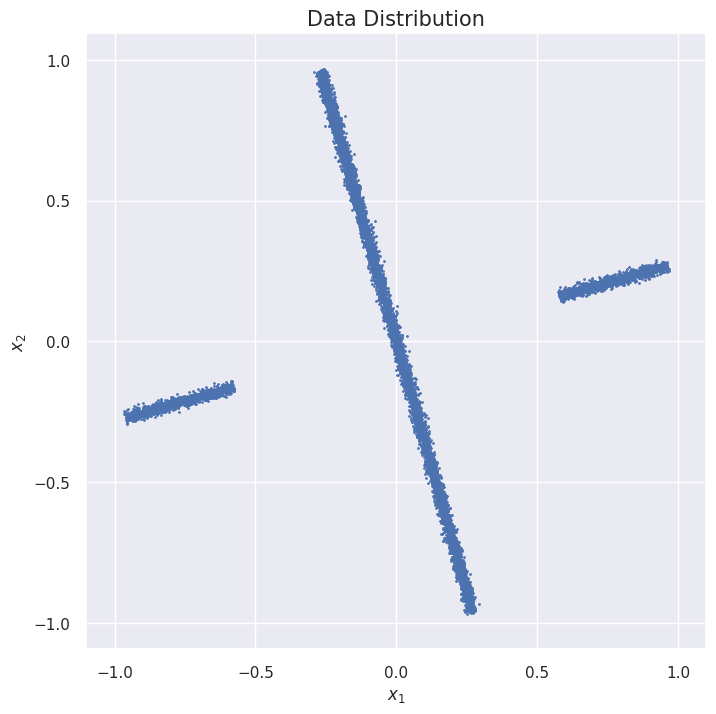

In [19]:
# plot data
fig = plt.figure(figsize=(8, 8))
plt.scatter(train[:, 0], train[:, 1], s=1)
plt.axis('equal')

plt.xlim(-1.1, 1.1)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='x', length=8)
plt.xlabel('$x_1$', fontsize=12)

plt.ylim(-1.1, 1.1)
plt.yticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='y', length=8)
plt.ylabel('$x_2$', fontsize=12)

plt.title('Data Distribution', fontsize=15)
plt.show()

In [20]:
# re-train model on rotated data
train_tr = torch.from_numpy(train).float()
test_tr = torch.from_numpy(test).float()

# training
model = Denoiser(n_node=32, n_int=4, bias=True)
epoch_loss, test_loss = train_simple(train_tr, test_tr, model, args)

In [21]:
x = np.linspace(-1.2, 1.2, 21)
y = np.linspace(-1.2, 1.2, 21)

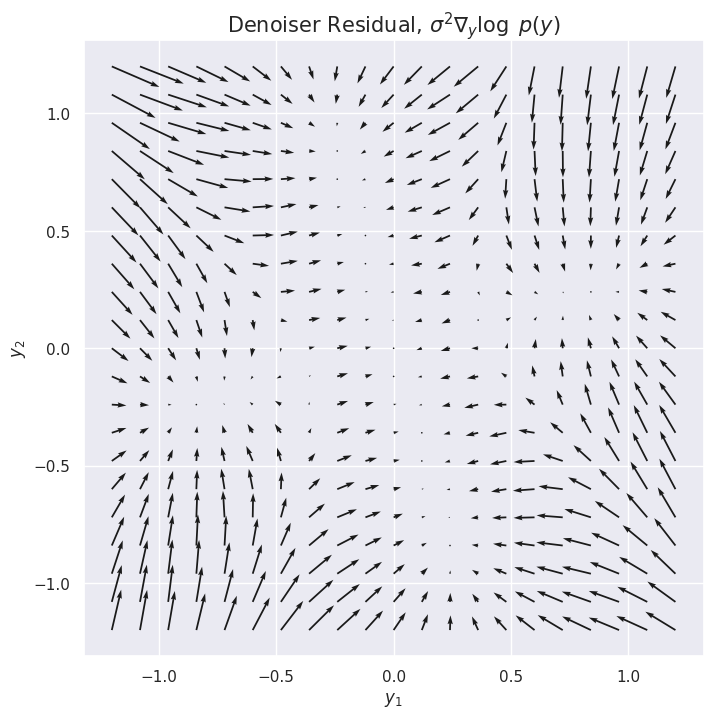

In [22]:
X, Y = np.meshgrid(x, y)
XY = np.concatenate([X.reshape(-1, 1), Y.reshape(-1, 1)], axis=1)

# compute the vector field (log prior gradient)
XY_tr = torch.from_numpy(XY).float()
with torch.no_grad():
    UV = - model(XY_tr.to(device)).detach().cpu().numpy()

U = UV[:, 0].reshape(X.shape)
V = UV[:, 1].reshape(Y.shape)

# generate the quiver plot
fig = plt.figure(figsize=(8, 8))
plt.quiver(X, Y, U, V, scale=12)

plt.xlabel('$y_1$', fontsize=12)
plt.ylabel('$y_2$', fontsize=12)

plt.axis('equal')
plt.title('Denoiser Residual, $\sigma^2 \\nabla_y \log \ p(y)$', fontsize=15)
plt.show()

Reconstruction as Function of Measurement

In [23]:
# setup
solver = inv.LinearInverse(model).to(device)
solver.h = 0.20
solver.beta = 0.20

solver.assign(torch.tensor([1, 0]).float().reshape([1, 2]).to(device))

In [24]:
if dist == 'ksparse':
    m = solver.measure(test_tr.to(device))
    m = torch.sort(m.flatten())[0].reshape(-1, 1)

else:
    # measurements along the x-axis
    m = np.linspace(-1.0, 1.0, 101)
    m = torch.tensor(m).float().reshape(-1, 1).to(device)

n_avg = 2048
# average reconstruction
with torch.no_grad():
    recon = torch.zeros(m.shape[0], 2).to(device)
    for i in range(n_avg):
        recon += solver.inverse(m).detach()
    recon = (recon / n_avg).cpu().numpy()

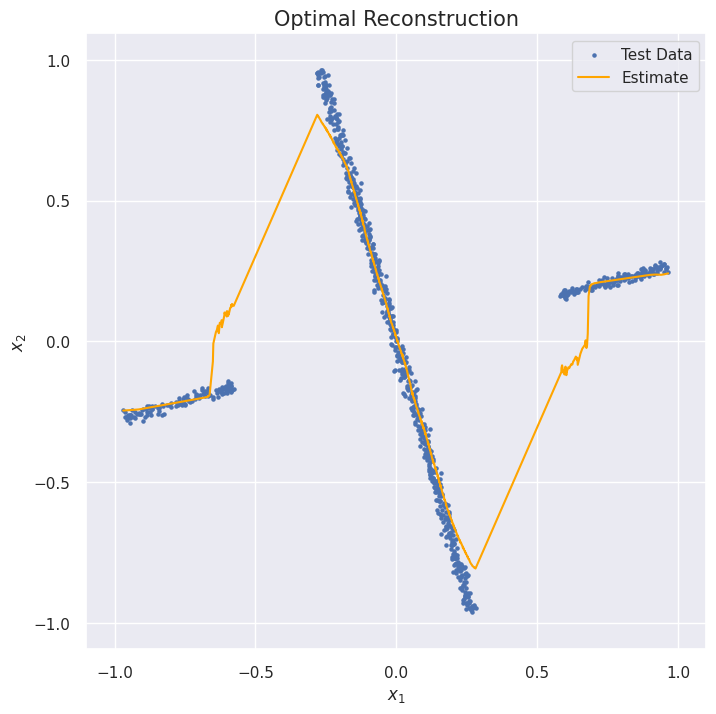

In [25]:
# plot data
fig = plt.figure(figsize=(8, 8))
plt.scatter(test[:, 0], test[:, 1], s=5,
            label='Test Data')
plt.plot(recon[:, 0], recon[:, 1],
            color='orange', label='Estimate')
plt.axis('equal')

plt.xlim(-1.1, 1.1)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='x', length=8)
plt.xlabel('$x_1$', fontsize=12)

plt.ylim(-1.1, 1.1)
plt.yticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='y', length=8)
plt.ylabel('$x_2$', fontsize=12)

plt.legend()
fig_name = 'Optimal Reconstruction'
plt.title(fig_name, fontsize=15)
plt.show()